In [1]:
import pandas as pd
df=pd.read_csv("warehouse_demand_prediction.csv")

In [2]:
df.head()

,Date,Product_ID,Warehouse_ID,Product_Category,Inventory_Level,Units_Sold,Price,Discount,Promotion,Holiday,Temperature,Demand
0,2023-01-01,P001,W001,Electronics,540,171,54.31,10,1,0,22.8,171
1,2023-01-01,P001,W002,Electronics,523,131,52.36,15,1,0,26.5,141
2,2023-01-01,P001,W003,Electronics,617,124,53.92,0,0,0,21.6,133
3,2023-01-01,P001,W004,Electronics,550,121,54.26,0,0,0,23.5,123
4,2023-01-01,P002,W001,Electronics,505,158,70.65,0,0,0,22.7,170


In [3]:
df.isnull().sum()

Date                0
Product_ID          0
Warehouse_ID        0
Product_Category    0
Inventory_Level     0
Units_Sold          0
Price               0
Discount            0
Promotion           0
Holiday             0
Temperature         0
Demand              0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35072 entries, 0 to 35071
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              35072 non-null  object 
 1   Product_ID        35072 non-null  object 
 2   Warehouse_ID      35072 non-null  object 
 3   Product_Category  35072 non-null  object 
 4   Inventory_Level   35072 non-null  int64  
 5   Units_Sold        35072 non-null  int64  
 6   Price             35072 non-null  float64
 7   Discount          35072 non-null  int64  
 8   Promotion         35072 non-null  int64  
 9   Holiday           35072 non-null  int64  
 10  Temperature       35072 non-null  float64
 11  Demand            35072 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.2+ MB


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [6]:
df["Date"]=pd.to_datetime(df["Date"])
df["year"]=df["Date"].dt.year
df["month"]=df["Date"].dt.month
df["day"]=df["Date"].dt.day

In [7]:
le=LabelEncoder()
df["Product_ID"]=le.fit_transform(df["Product_ID"])
df["Warehouse_ID"]=le.fit_transform(df["Warehouse_ID"])
df["Product_Category"]=le.fit_transform(df["Product_Category"])

In [8]:
df

,Date,Product_ID,Warehouse_ID,Product_Category,Inventory_Level,Units_Sold,Price,Discount,Promotion,Holiday,Temperature,Demand,year,month,day
0,2023-01-01,0,0,1,540,171,54.31,10,1,0,22.8,171,2023,1,1
1,2023-01-01,0,1,1,523,131,52.36,15,1,0,26.5,141,2023,1,1
2,2023-01-01,0,2,1,617,124,53.92,0,0,0,21.6,133,2023,1,1
3,2023-01-01,0,3,1,550,121,54.26,0,0,0,23.5,123,2023,1,1
4,2023-01-01,1,0,1,505,158,70.65,0,0,0,22.7,170,2023,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35067,2025-12-31,6,3,3,588,161,48.21,0,0,0,22.2,161,2025,12,31
35068,2025-12-31,7,0,3,525,111,64.36,0,0,0,24.9,132,2025,12,31
35069,2025-12-31,7,1,3,457,80,67.53,0,0,0,22.1,81,2025,12,31
35070,2025-12-31,7,2,3,733,163,67.91,0,1,0,23.3,177,2025,12,31


In [9]:
x=df.drop(columns=["Date","Demand"])

In [10]:
y=df["Demand"]

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
model=RandomForestClassifier(n_estimators=20,random_state=42,n_jobs=-1)  #n_jobs=-1 use all avilable cpu cores


In [15]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [16]:
df.shape

(35072, 15)

In [17]:
y_pred=model.predict(x_test)

In [18]:
print("MAE:",mean_absolute_error(y_test,y_pred))

MAE: 6.409693513898788


In [ ]:
print("RMSE:",mean_squared_error(y_test,y_pred)**0.5)

MSE: 9.359578549277728


In [20]:
print("r2_score:",r2_score(y_test,y_pred))

r2_score: 0.9330141024932075


In [28]:
import matplotlib.pyplot as plt

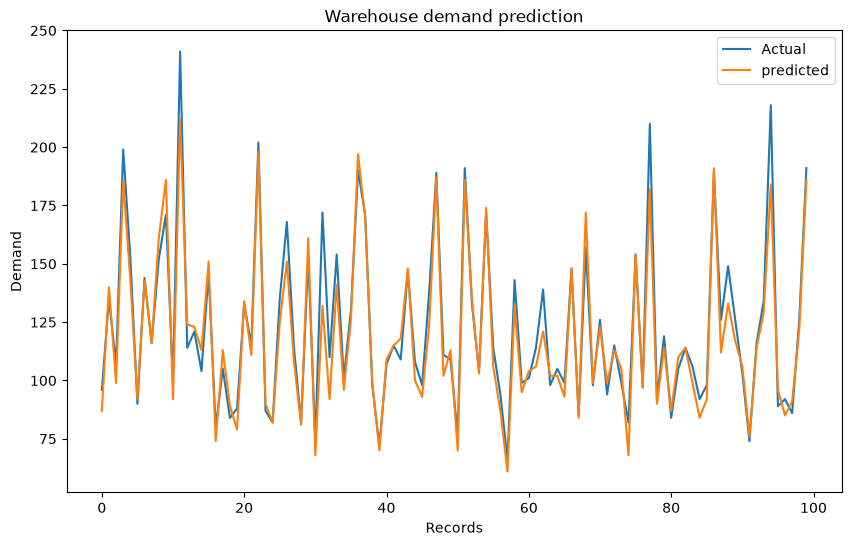

In [29]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:100],label="Actual")
plt.plot(y_pred[:100],label="predicted")
plt.xlabel("Records")
plt.ylabel("Demand")
plt.title("Warehouse demand prediction")
plt.legend()
plt.show()

